In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt
from src.analysis import break_even_analysis, comparative_statics, stochastic_bivariate_simulation, run_monte_carlo, \
    run_two_way_sensitivity_analysis
from src.config import variable_names
from src.engine import evaluate_chained_models, evaluate_variable_scenario_sweep, evaluate_expected_scenario
from src.models import ProfitModel, CostOfGoodsSoldModel, RevenueModel, FreeCashFlowModel, \
    CapitalExpenditureModel, DepreciationModel, TotalExpenseModel, NetIncomeModel, RoiModel, TotalCostModel, \
    AdvertisingEfficiencyModel
from src.variables import Orders, SellingPrice, PurchasingPrice, ItemsPerOrder, USDToRMB, Rent, TaxRate, \
    CostPerAcquisition, ConversionRate, RenderFee, TravelFee, AdvertisingCost, Expense
from src.visualization import generate_histogram_from_array

In [2]:
orders = Orders(min_value=20, max_value=30)
usd_to_rmb = USDToRMB(expected_value=1)
selling_price = SellingPrice(min_value=3000, max_value=6000)
items_per_order = ItemsPerOrder(min_value=1, max_value=5)
purchasing_price = PurchasingPrice(min_value=1000, max_value=2000)

variables = {variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
           variable_names.DEAL_ORDERS: orders,
           variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
           variable_names.DEAL_SELLING_PRICE: selling_price,
           variable_names.DEAL_ITEMS_PER_ORDER: items_per_order}

cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = TotalExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
# advertising_efficiency_model = AdvertisingEfficiencyModel()
# free_cash_flow_model = FreeCashFlowModel()
profit_model = ProfitModel()

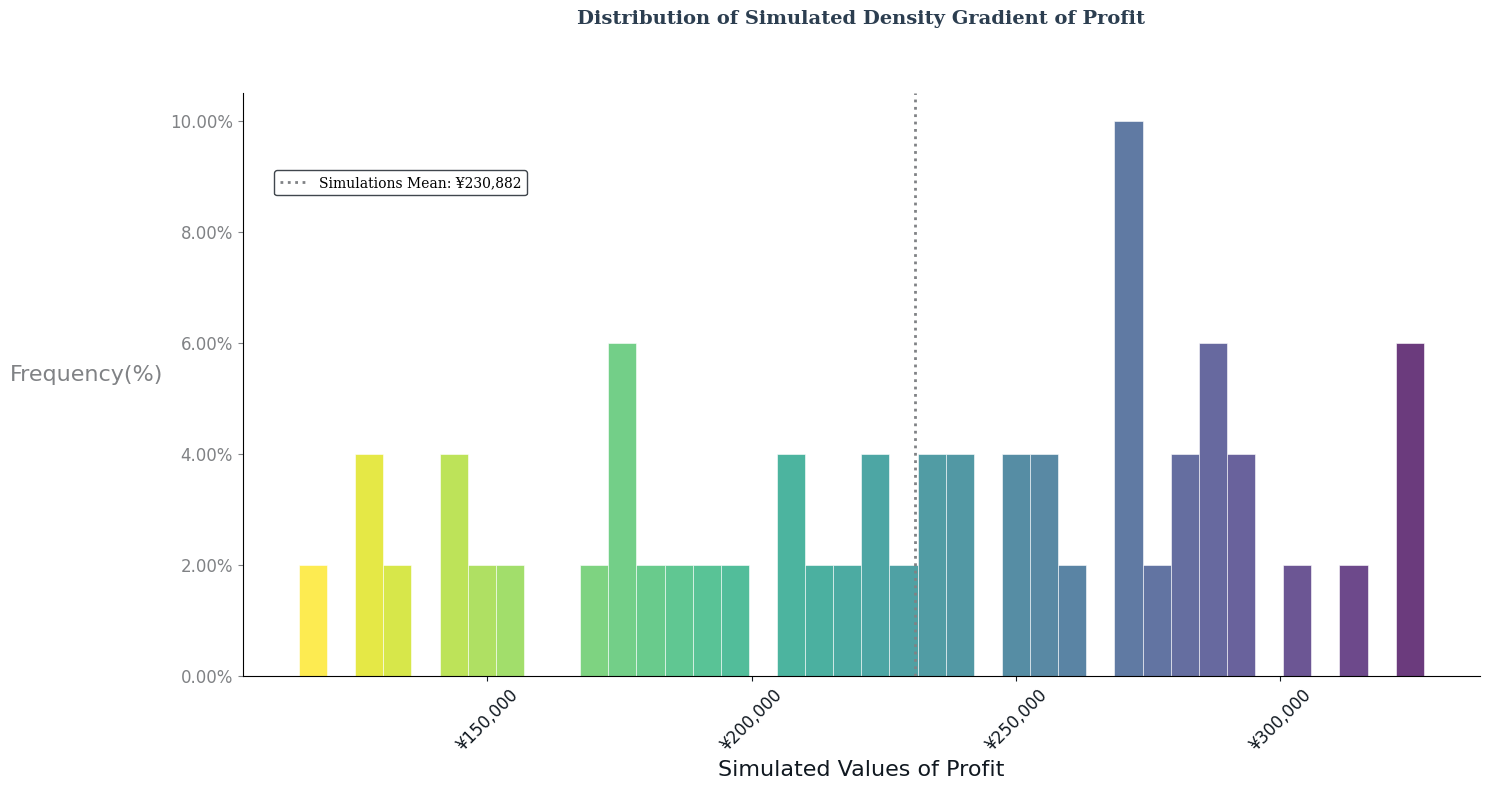

In [3]:
simulations = run_monte_carlo(variables, [variable_names.DEAL_PURCHASING_PRICE,
                                          variable_names.DEAL_SELLING_PRICE],
                              [cogs_model, revenue_model, cost_model, expense_model, depreciation_model,
                               capital_expenditure_model, profit_model],
                              tracked_outputs=[variable_names.PROFIT],
                              iterations=50)
generate_histogram_from_array(simulations, variable_names.PROFIT)
plt.show()

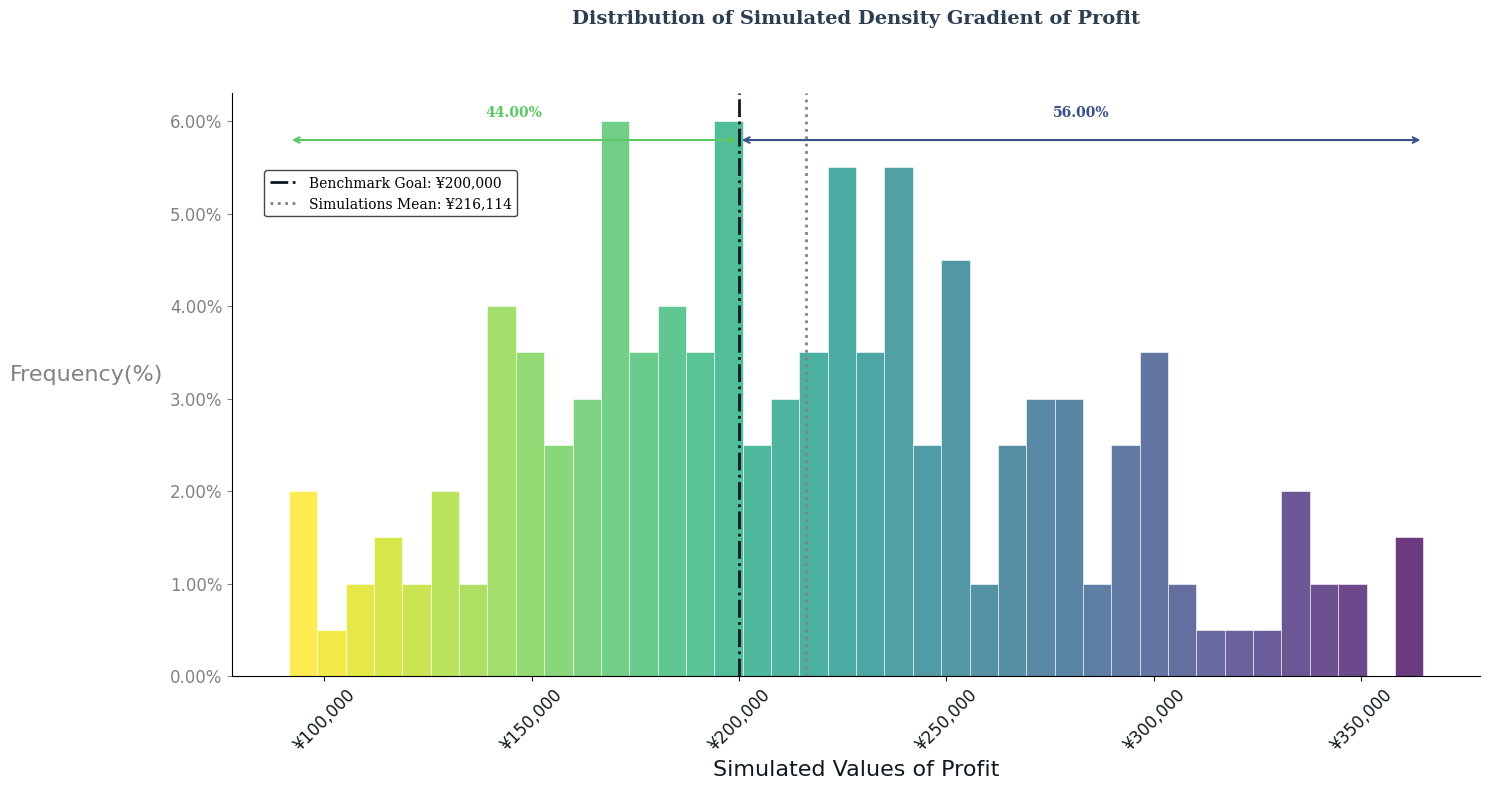

In [4]:
simulations = run_monte_carlo(variables, [variable_names.DEAL_PURCHASING_PRICE,
                                          variable_names.DEAL_SELLING_PRICE],
                              [cogs_model, revenue_model, cost_model, expense_model, depreciation_model,
                               capital_expenditure_model, profit_model],
                              tracked_outputs=[variable_names.PROFIT],
                              iterations=200)

benchmark_goal = 200000
generate_histogram_from_array(simulations, variable_names.PROFIT, benchmark_goal)
plt.show()

## Simulation 2

In [5]:
from src.models import CostOfGoodsSoldModel, TotalCostModel, RevenueModel, TotalExpenseModel, DepreciationModel, \
    CapitalExpenditureModel, NetIncomeModel, ProfitModel, AdvertisingEfficiencyGoogleSearchModel, \
    CostPerLeadGoogleSearchModel, RoasModel, OrderModel
from src.variables import GoogleSearchCostPerClick, AdvertisingBudget, GoogleSearchAllocationPercentage, \
    GoogleSearchConversionRate, CloseRate, ItemsPerOrder, SellingPrice, PurchasingPrice, USDToRMB

In [6]:
budget = AdvertisingBudget(3000, 2000, 5000)
google_search_allocation = GoogleSearchAllocationPercentage(0.6, 0.5, 0.7)
cpc = GoogleSearchCostPerClick(2.5, 1.8, 3.5)
cvr = GoogleSearchConversionRate(0.04, 0.02, 0.06)
close_rate = CloseRate(0.12, 0.08, 0.18)

items_per_order = ItemsPerOrder(2, 1.5, 3)
# selling_price = SellingPrice(8000, 5000, 10000)
selling_price = SellingPrice(3000, 2000, 4000)
purchasing_price = PurchasingPrice(2000, 1100, 2500)

usd_to_rmb = USDToRMB(6.8, 6.0, 7.5)

variables = {
    variable_names.COST_ADVERTISING: budget,
    variable_names.ALLOCATION_GOOGLE_SEARCH: google_search_allocation,
    variable_names.CPC_GOOGLE_SEARCH: cpc,
    variable_names.CONVERSION_RATE_GOOGLE_SEARCH: cvr,
    variable_names.CLOSE_RATE: close_rate,
    variable_names.DEAL_SELLING_PRICE: selling_price,
    variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
    variable_names.DEAL_ITEMS_PER_ORDER: items_per_order,
    variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
}

cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = TotalExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
profit_model = ProfitModel()
order_model = OrderModel()

advertising_efficiency_google_search_model = AdvertisingEfficiencyGoogleSearchModel()
cost_per_lead_model = CostPerLeadGoogleSearchModel()
roas_model = RoasModel()

model_pipeline = [advertising_efficiency_google_search_model, order_model,
                  cogs_model, cost_model, revenue_model, net_income_model, profit_model, cost_per_lead_model, roas_model]

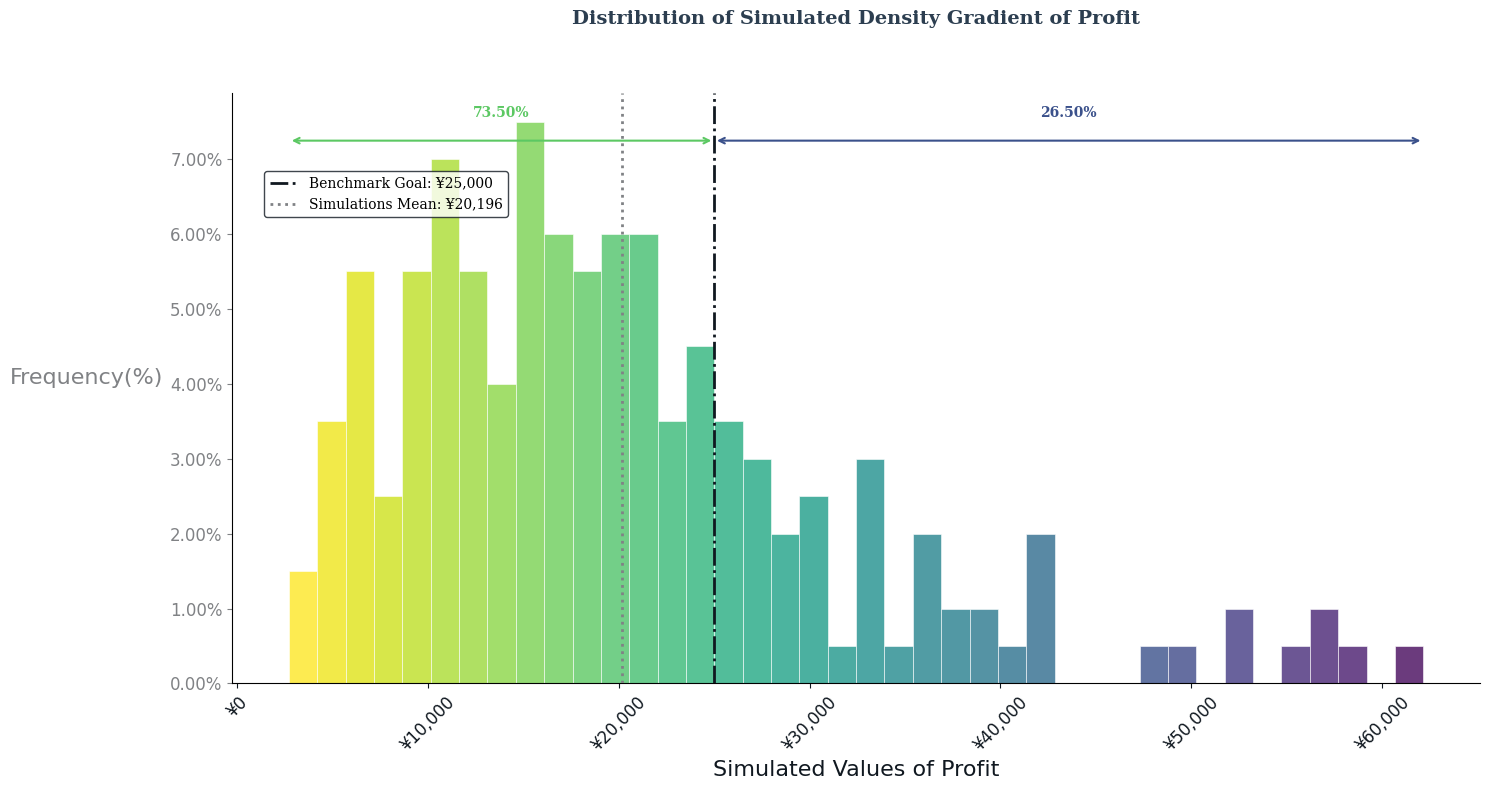

In [7]:
simulations_2 = run_monte_carlo(variables, [variable_names.COST_ADVERTISING,
                                          variable_names.CPC_GOOGLE_SEARCH,variable_names.CONVERSION_RATE_GOOGLE_SEARCH,
                                          variable_names.CLOSE_RATE, variable_names.DEAL_SELLING_PRICE],
                              model_pipeline,
                              tracked_outputs=[variable_names.PROFIT, variable_names.CPL_GOOGLE_SEARCH],
                              iterations=200)

benchmark_goal = 25000
generate_histogram_from_array(simulations_2, variable_names.PROFIT, benchmark_goal)
plt.show()

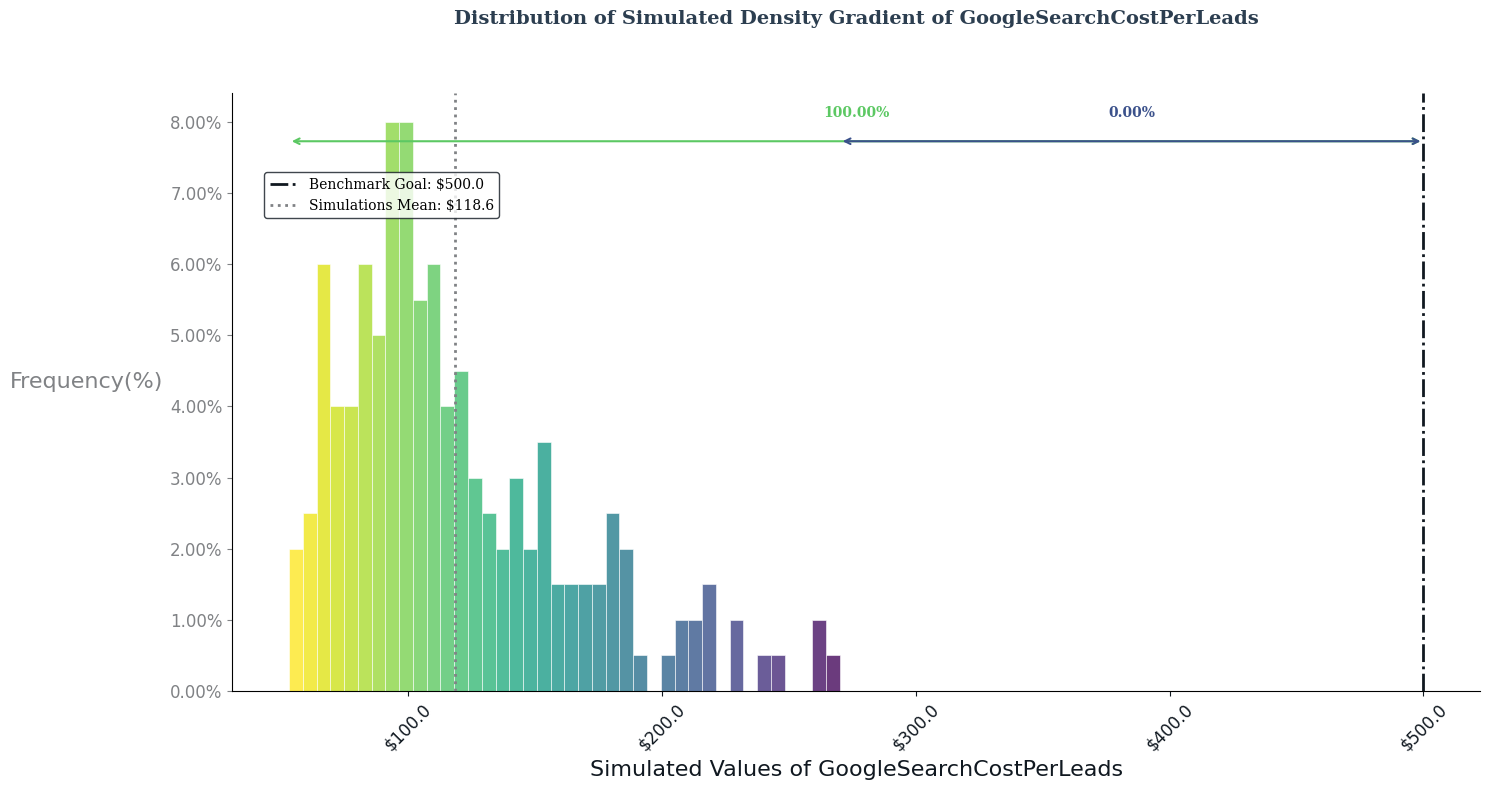

In [8]:
benchmark_goal = 500
generate_histogram_from_array(simulations_2, variable_names.CPL_GOOGLE_SEARCH, benchmark_goal)
plt.show()